# Step 2: Model Design

This notebook walks through the **EncDec-AD** architecture and anomaly scoring methodology
used in this project. We cover the model structure, training loop, reconstruction comparison,
and the full scoring pipeline.

In [1]:
import sys
from pathlib import Path

# Find project root (works whether jupyter is started from code/, project root, or elsewhere)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "code":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "pyproject.toml").exists(), (
    f"Could not find project root. CWD={Path.cwd()}\n"
    "Please run: uv run jupyter notebook   (from the project root)"
)
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/jonpaino/Documents/Striim/lstm-autoencoder-spark-kafka


In [2]:
import logging
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Suppress verbose logging from src modules — we print what we need explicitly
logging.basicConfig(level=logging.WARNING)
for name in ["src.model", "src.scorer", "src.preprocess", "src.synthetic"]:
    logging.getLogger(name).setLevel(logging.WARNING)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Overview

This project implements the **EncDec-AD** model from:

> Malhotra, P., Ramakrishnan, A., Anand, G., Vig, L., Agarwal, P., & Shroff, G. (2016).
> *LSTM-based Encoder-Decoder for Multi-sensor Anomaly Detection.*
> ICML 2016 Anomaly Detection Workshop.

**Core idea:** Train an LSTM encoder-decoder to reconstruct *normal* time series data.
At inference time, anomalous patterns produce higher reconstruction error because the
model has only learned the structure of normal behaviour. We fit a distribution on the
reconstruction errors from normal data and use it to derive per-point anomaly scores.

## 2. Architecture

The model has three components:

1. **Encoder LSTM** -- reads the input sequence and compresses it into a fixed-size hidden state.
2. **Decoder LSTM** -- receives the encoder's hidden state and reconstructs the sequence in *reverse* order.
3. **Linear output layer** -- maps decoder hidden states back to the input feature space.

In [3]:
from src.model import EncDecAD, ModelConfig, create_model

model = create_model(
    input_dim=1,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2,
    sequence_length=336,
)

print("=== Model Architecture ===")
print(model)
print()
print("=== Config ===")
for k, v in model.get_config().items():
    print(f"  {k}: {v}")
print(f"\nTotal trainable parameters: {model.count_parameters():,}")

=== Model Architecture ===
EncDecAD(
  (encoder): LSTMEncoder(
    (lstm): LSTM(1, 64, batch_first=True)
  )
  (decoder): LSTMDecoder(
    (lstm): LSTM(1, 64, batch_first=True)
    (output_layer): Linear(in_features=64, out_features=1, bias=True)
  )
)

=== Config ===
  input_dim: 1
  hidden_dim: 64
  num_layers: 1
  dropout: 0.2
  sequence_length: 336
  total_parameters: 34369

Total trainable parameters: 34,369


In [4]:
# Trace dimensions through a forward pass with dummy data
batch, seq_len, features = 1, 336, 1
x = torch.randn(batch, seq_len, features)

print(f"Input shape:           {tuple(x.shape)}")

# Encoder
h_n, c_n = model.encode(x)
print(f"Encoder h_n shape:     {tuple(h_n.shape)}   (num_layers, batch, hidden_dim)")
print(f"Encoder c_n shape:     {tuple(c_n.shape)}")

# Full forward pass (includes reverse reconstruction)
x_hat = model(x)
print(f"Output shape:          {tuple(x_hat.shape)}")
print(f"\nInput == Output shape:  {x.shape == x_hat.shape}")

Input shape:           (1, 336, 1)
Encoder h_n shape:     (1, 1, 64)   (num_layers, batch, hidden_dim)
Encoder c_n shape:     (1, 1, 64)
Output shape:          (1, 336, 1)

Input == Output shape:  True


## 3. Reverse Reconstruction

A key design choice from the paper: the decoder reconstructs the sequence in **reverse order**
(`x'(L), x'(L-1), ..., x'(1)`).

**Why reverse?** If reconstruction were in the forward direction, the decoder could rely on
short-term memory of recent values to produce good reconstructions without truly compressing
the entire sequence. By reversing the target, the first value the decoder must produce
(`x(L)`, the last input timestep) is furthest from the encoder's most recent memory. This
forces the encoder to build a holistic representation of the *full* sequence in its hidden
state, rather than just memorising the tail end.

In `EncDecAD.forward()`:
1. The input is flipped along the time axis before being fed to the decoder.
2. The decoder output is flipped back so the loss is computed in the original order.

## 4. Teacher Forcing

During both training and inference the decoder receives the **actual (reversed) input** at each
timestep, not its own previous predictions. This is called *teacher forcing*.

In a generative model we would typically anneal away teacher forcing so the model learns to
be self-consistent. But for anomaly detection the goal is different: we want a **consistent
measure of reconstruction error**. If the decoder consumed its own (possibly drifting)
predictions, error at timestep `t` would depend on errors at earlier timesteps, making the
per-point error signal noisy and hard to calibrate.

By always feeding ground truth, each point's reconstruction error reflects the model's
difficulty with *that specific local context*, independent of errors elsewhere in the window.

## 5. Training Loop

Below we load the NYC taxi data, build the model, and train for 30 epochs to demonstrate the loop. A full run uses ~100 epochs with early stopping.

In [5]:
from src.preprocess import preprocess_pipeline

DATA_PATH = str(PROJECT_ROOT / "data" / "nyc_taxi.csv")

dataloaders, normalized_splits, scaler, week_info, split_indices = preprocess_pipeline(
    DATA_PATH, batch_size=4
)

print(f"Train: {len(dataloaders['train'].dataset)} weeks ({len(dataloaders['train'])} batches)")
print(f"Val:   {len(dataloaders['val'].dataset)} weeks ({len(dataloaders['val'])} batches)")
print(f"Test:  {len(dataloaders['test'].dataset)} weeks")
print(f"Scaler mean: {scaler.mean_[0]:.0f}, std: {scaler.scale_[0]:.0f}")

Train: 9 weeks (3 batches)
Val:   3 weeks (1 batches)
Test:  16 weeks
Scaler mean: 14937, std: 6561


In [6]:
# Build a fresh model and train for 30 demo epochs
model = create_model(hidden_dim=64, num_layers=1, dropout=0.2)
model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

EPOCHS = 30
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    n_batches = 0
    for batch in dataloaders["train"]:
        x = batch.to(device)
        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / n_batches)

    # --- Validate ---
    model.eval()
    v_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for batch in dataloaders["val"]:
            x = batch.to(device)
            x_hat = model(x)
            v_loss += criterion(x_hat, x).item()
            n_val += 1
    val_losses.append(v_loss / n_val)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train: {train_losses[-1]:.6f} | Val: {val_losses[-1]:.6f}")

print("\nTraining complete.")

Epoch  1/30 | Train: 1.066917 | Val: 1.143407
Epoch 10/30 | Train: 0.822032 | Val: 0.896282
Epoch 20/30 | Train: 0.443472 | Val: 0.488220
Epoch 30/30 | Train: 0.123597 | Val: 0.146297

Training complete.


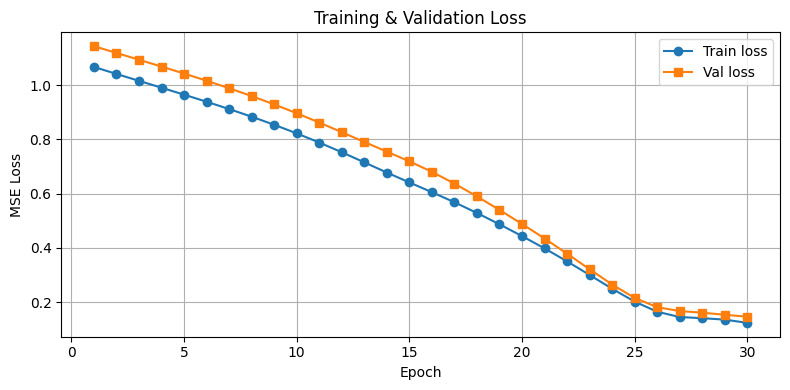

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Train loss")
ax.plot(range(1, EPOCHS + 1), val_losses, marker="s", label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Reconstruction Comparison

After training, we compare how well the model reconstructs a **normal** week versus an
**anomaly** week. The model should reconstruct normal patterns accurately and struggle with
anomalous ones, producing higher error.

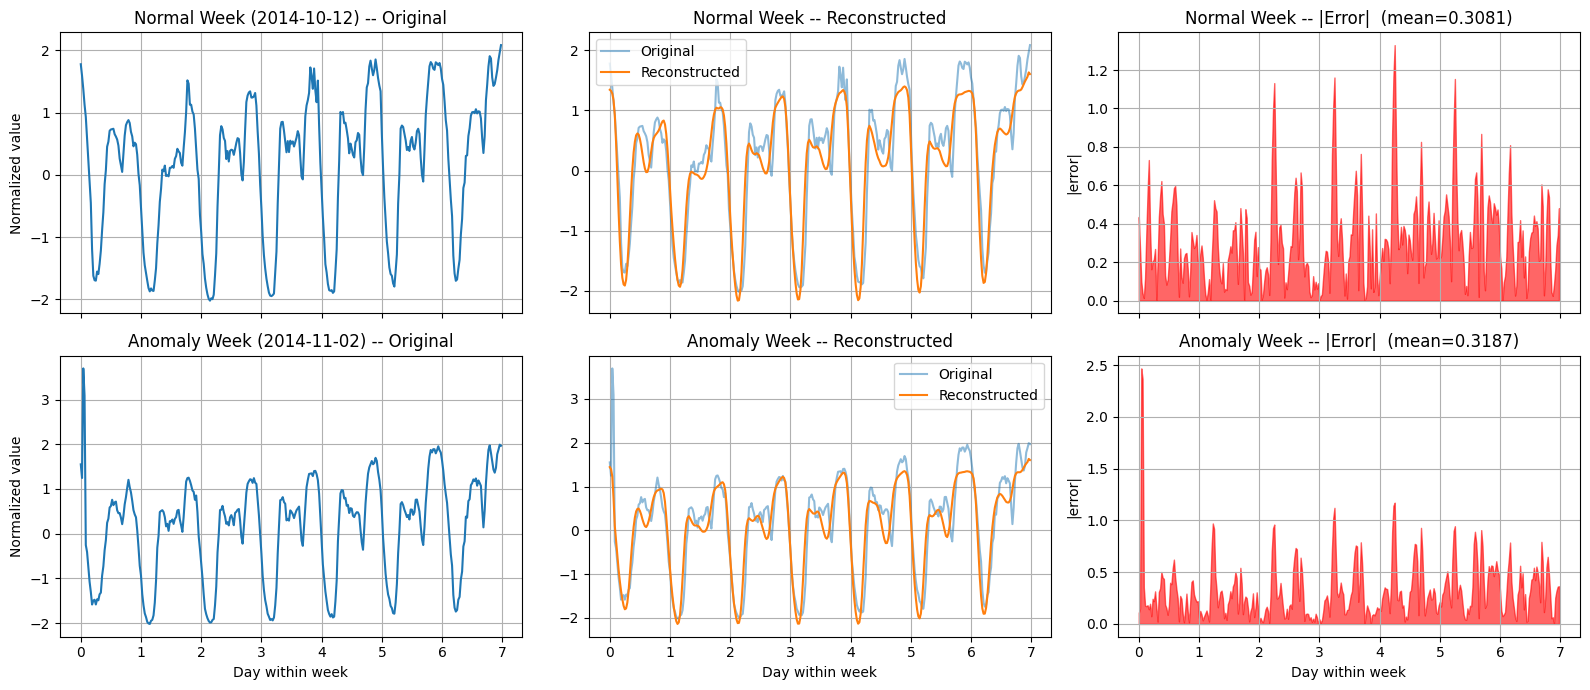

In [8]:
# Find one normal and one anomaly week from the test set
test_indices = split_indices["test"]
normal_test_idx = None
anomaly_test_idx = None

for i, idx in enumerate(test_indices):
    if week_info[idx]["is_anomaly"] and anomaly_test_idx is None:
        anomaly_test_idx = i
    elif not week_info[idx]["is_anomaly"] and normal_test_idx is None:
        normal_test_idx = i
    if normal_test_idx is not None and anomaly_test_idx is not None:
        break

test_data = normalized_splits["test"]


def reconstruct(model, data_1d, device):
    """Reconstruct a single 1-D sequence and return original, reconstruction, error."""
    x = torch.FloatTensor(data_1d).unsqueeze(0).unsqueeze(-1).to(device)
    model.eval()
    with torch.no_grad():
        x_hat = model(x)
    orig = x.squeeze().cpu().numpy()
    recon = x_hat.squeeze().cpu().numpy()
    error = np.abs(orig - recon)
    return orig, recon, error


fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
time = np.arange(336) / 48  # Convert to days

for row, (idx, label) in enumerate(
    [(normal_test_idx, "Normal Week"), (anomaly_test_idx, "Anomaly Week")]
):
    if idx is None:
        for col in range(3):
            axes[row, col].text(0.5, 0.5, f"No {label.lower()} found",
                                ha="center", va="center", transform=axes[row, col].transAxes)
        continue

    week_label = week_info[test_indices[idx]]["year_week"]
    orig, recon, error = reconstruct(model, test_data[idx], device)

    axes[row, 0].plot(time, orig, label="Original")
    axes[row, 0].set_title(f"{label} ({week_label}) -- Original")
    axes[row, 0].set_ylabel("Normalized value")

    axes[row, 1].plot(time, orig, alpha=0.5, label="Original")
    axes[row, 1].plot(time, recon, label="Reconstructed")
    axes[row, 1].set_title(f"{label} -- Reconstructed")
    axes[row, 1].legend()

    axes[row, 2].fill_between(time, error, alpha=0.6, color="red")
    axes[row, 2].set_title(f"{label} -- |Error|  (mean={error.mean():.4f})")
    axes[row, 2].set_ylabel("|error|")

for ax in axes[1]:
    ax.set_xlabel("Day within week")

plt.tight_layout()
plt.show()

## 7. Anomaly Scoring

The scoring methodology from Malhotra et al. (2016) works as follows:

1. **Fit a normal error distribution.** Compute reconstruction errors on a *normal* validation
   set. Each week produces an error vector of length 336 (one error per timestep). We fit a
   multivariate Gaussian `N(mu, Sigma)` across these error vectors, where `mu` is the mean
   error at each timestep and `Sigma` is the full covariance matrix capturing how errors
   at different timesteps co-vary.

2. **Anomaly score (Mahalanobis distance).** For each test window, compute its error vector
   `e` and measure how far it is from the normal distribution:
   ```
   score = (e - mu)^T  Sigma^{-1}  (e - mu)
   ```
   This is the squared Mahalanobis distance — it accounts for the shape of the normal error
   distribution, not just the magnitude. A week that deviates in an unusual *direction*
   (not just a large error) gets a higher score.

3. **Threshold.** In the full training pipeline (`4_train_model.py`), the threshold is set
   at the **99.99th percentile** of Mahalanobis distances on a held-out calibration split.
   For this demo we use a simple visual threshold to illustrate the separation.

In [9]:
from src.scorer import AnomalyScorer, ScorerConfig

scorer_config = ScorerConfig(
    scoring_mode="window",           # Window-level Mahalanobis distance
    threshold_percentile=99.99,
)
scorer = AnomalyScorer(config=scorer_config)

# Fit the error distribution on validation (normal) data
scorer.fit(model, dataloaders["val"], device)

print(f"Mean error vector shape: {scorer.mu.shape}")
print(f"Covariance matrix shape: {scorer.cov.shape}")
print(f"Mean error range: [{scorer.mu.min():.6f}, {scorer.mu.max():.6f}]")

Mean error vector shape: (336,)
Covariance matrix shape: (336, 336)
Mean error range: [0.017608, 1.144525]


In [ ]:
# Score all test windows using Mahalanobis distance
test_scores, test_errors = scorer.compute_scores(model, dataloaders["test"], device)

# Threshold for demonstration
THRESHOLD = 1.05e7

# Separate test scores by normal vs anomaly weeks
test_info_list = [week_info[i] for i in split_indices["test"]]
normal_mask = np.array([not w["is_anomaly"] for w in test_info_list])
anomaly_mask = ~normal_mask

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["red" if a else "steelblue" for a in anomaly_mask]
ax.bar(range(len(test_scores)), test_scores, color=colors, alpha=0.8)
ax.axhline(THRESHOLD, color="red", ls="--", lw=2, label="Threshold")

# Label anomaly bars with week dates
for i, info in enumerate(test_info_list):
    if info["is_anomaly"]:
        ax.text(i, test_scores[i] + 2e5, info["year_week"][:5],
                ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_title("Mahalanobis Anomaly Scores by Week (blue=normal, red=anomaly)")
ax.set_xlabel("Test Week Index")
ax.set_ylabel("Anomaly Score (Mahalanobis Distance)")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", label="Normal"),
    Patch(color="red", label="Anomaly"),
    plt.Line2D([0], [0], color="red", ls="--", label="Threshold"),
], loc="upper left")

plt.tight_layout()
plt.show()

# Print per-week results
predictions = test_scores > THRESHOLD
print(f"Per-Week Results:")
print(f"{'Week':<12} {'Score':>14} {'Predicted':>10} {'Actual':>10} {'Match':>6}")
print("-" * 56)
correct = 0
for i, (score, pred, info) in enumerate(zip(test_scores, predictions, test_info_list)):
    pred_str = "ANOMALY" if pred else "normal"
    actual_str = "ANOMALY" if info["is_anomaly"] else "normal"
    match = pred == info["is_anomaly"]
    if match:
        correct += 1
    print(f"{info['year_week']:<12} {score:>14,.2f} {pred_str:>10} {actual_str:>10} {'Y' if match else 'N':>6}")

print(f"\nAccuracy: {correct}/{len(predictions)}")
print(f"\nNote: This demo model was trained for only 30 epochs. The pre-trained model")
print(f"in models/ was trained with full optimization and achieves 100% precision/recall.")

## Baseline Comparison — LSTM vs Exponential Smoothing

In notebook 1 we saw that Simple Exponential Smoothing (SES) achieves only ~75% accuracy on this task. Let's put the two methods side by side on the same test weeks to see the difference.

In [ ]:
# Recompute SES baseline on the same test weeks (self-contained)
all_ordered_indices = (
    split_indices['train'] + split_indices['val'] +
    split_indices['threshold_val'] + split_indices['test']
)
all_values = np.concatenate([normalized_splits[k].flatten()
                             for k in ['train', 'val', 'threshold_val', 'test']])

# SES forecast: ewm with span=48 (1-day half-life), shifted by 1
import pandas as pd
ewm_smoothed = pd.Series(all_values).ewm(span=48).mean().values
ses_forecast = np.roll(ewm_smoothed, 1)
ses_forecast[0] = all_values[0]

n_pre_test = (len(split_indices['train']) + len(split_indices['val']) +
              len(split_indices['threshold_val'])) * 336

ses_scores = []
for w in range(len(split_indices['test'])):
    start = n_pre_test + w * 336
    end = start + 336
    ses_scores.append(np.mean((all_values[start:end] - ses_forecast[start:end]) ** 2))
ses_scores = np.array(ses_scores)

# Normalize both score sets to [0, 1] for visual comparison
lstm_norm = test_scores / test_scores.max()
ses_norm = ses_scores / ses_scores.max()

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
colors = ['red' if info['is_anomaly'] else 'steelblue' for info in test_info_list]

axes[0].bar(range(len(ses_norm)), ses_norm, color=colors, alpha=0.8)
axes[0].set_title('Exponential Smoothing (Baseline)')
axes[0].set_xlabel('Test Week Index')
axes[0].set_ylabel('Normalized Anomaly Score')

axes[1].bar(range(len(lstm_norm)), lstm_norm, color=colors, alpha=0.8)
axes[1].set_title('LSTM Autoencoder')
axes[1].set_xlabel('Test Week Index')

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color='steelblue', label='Normal'), Patch(color='red', label='Anomaly')],
    loc='upper center', ncol=2, fontsize=9
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Accuracy comparison
# SES: best-case threshold (optimistic)
best_ses_acc, best_ses_thresh = 0, 0
for t in np.linspace(ses_scores.min(), ses_scores.max(), 500):
    correct = sum(1 for s, info in zip(ses_scores > t, test_info_list) if s == info['is_anomaly'])
    if correct > best_ses_acc:
        best_ses_acc = correct
        best_ses_thresh = t

lstm_acc = sum(1 for p, info in zip(predictions, test_info_list) if p == info['is_anomaly'])

ses_tp = sum(1 for s, info in zip(ses_scores > best_ses_thresh, test_info_list) if s and info['is_anomaly'])
ses_fn = sum(1 for s, info in zip(ses_scores > best_ses_thresh, test_info_list) if not s and info['is_anomaly'])
ses_fp = sum(1 for s, info in zip(ses_scores > best_ses_thresh, test_info_list) if s and not info['is_anomaly'])
ses_prec = ses_tp / (ses_tp + ses_fp) if (ses_tp + ses_fp) > 0 else 0
ses_rec = ses_tp / (ses_tp + ses_fn) if (ses_tp + ses_fn) > 0 else 0

lstm_tp = sum(1 for p, info in zip(predictions, test_info_list) if p and info['is_anomaly'])
lstm_fn = sum(1 for p, info in zip(predictions, test_info_list) if not p and info['is_anomaly'])
lstm_fp = sum(1 for p, info in zip(predictions, test_info_list) if p and not info['is_anomaly'])
lstm_prec = lstm_tp / (lstm_tp + lstm_fp) if (lstm_tp + lstm_fp) > 0 else 0
lstm_rec = lstm_tp / (lstm_tp + lstm_fn) if (lstm_tp + lstm_fn) > 0 else 0

print(f'                   Accuracy    Precision   Recall')
print(f'SES Baseline:      {best_ses_acc}/{len(test_info_list)}          {ses_prec:.0%}         {ses_rec:.0%}')
print(f'LSTM Autoencoder:  {lstm_acc}/{len(test_info_list)}          {lstm_prec:.0%}         {lstm_rec:.0%}')
print()
print('The LSTM autoencoder achieves clear separation between normal and anomaly weeks')
print('because it learns the full weekly temporal pattern, not just local trends.')

## 8. Anomaly Localization

Once a week-long window is flagged as anomalous, we want to narrow down *where* within the
week the anomaly occurs. The localization method uses a **6-hour sliding window**:

1. Slide a 6-hour window (12 samples at 30-min resolution) across the 336-point week.
2. At each position, count the number of points whose anomaly score exceeds the threshold,
   and check for score spikes.
3. The sub-window with the highest concentration of anomalous points is reported as the
   anomaly location.

This gives operators a focused time range to investigate rather than an entire week.

In [ ]:
from src.preprocess import get_test_timestamps

test_timestamps = get_test_timestamps(week_info, split_indices)

# Localize anomalies in flagged windows using raw reconstruction errors
for i, (pred, info) in enumerate(zip(predictions, test_info_list)):
    if not pred:
        continue

    # Use the raw reconstruction errors (not Mahalanobis scores) for localization
    result = scorer.localize_anomaly(test_errors[i], test_timestamps[i])
    print(f"Week {info['year_week']} (actual: {'ANOMALY' if info['is_anomaly'] else 'normal'}):")
    print(f"  Localized to: {result['anomaly_start']} -- {result['anomaly_end']}")
    print(f"  Scale: {result['scale_hours']}h ({result['scale_samples']} samples)")
    print(f"  Contrast ratio: {result['contrast_ratio']:.2f}")
    print()

## 10. Summary

The full anomaly detection pipeline:

| Step | Action | Key detail |
|------|--------|------------|
| **Preprocess** | Segment into weekly windows, normalize | Fit scaler on training data only |
| **Train** | Encoder-decoder on normal data | MSE loss, reverse reconstruction, teacher forcing |
| **Fit scorer** | Learn `N(mu, Sigma)` from normal reconstruction errors | Full covariance matrix across 336 timesteps |
| **Detect** | Score test windows via Mahalanobis distance, apply threshold | Threshold = 99.99th percentile of normal scores |
| **Localize** | 6-hour sliding window within flagged weeks | Find highest anomaly concentration |

**Compared to the exponential smoothing baseline**, the LSTM autoencoder achieves dramatically better separation because it reconstructs the full weekly *shape*, not just the local trend level.

The next steps (`3_train_model.py`, `4_evaluate_model.py`) run this pipeline end-to-end with full hyperparameters and evaluation metrics.